# 08 — Uplift Model Comparison

## Objective

This notebook compares multiple uplift modeling approaches using the Criteo Uplift Dataset.

The models evaluated are:

- S-Learner
- T-Learner
- X-Learner

The objective is to determine which approach provides the strongest treatment-effect ranking.

All models will use the same:

- Features
- Train/test split
- Outcome variable
- Treatment assignment
- Evaluation dataset
- Uplift evaluation metrics

### Key Evaluation Metrics

- ROC-AUC
- PR-AUC
- Uplift@10%
- Uplift@20%
- Qini coefficient
- AUUC

The final comparison will identify the strongest uplift modeling approach for the project.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score,
    average_precision_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
DATA_PATH = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\raw\criteo-research-uplift-v2.1.csv.gz"
)

print("Dataset exists:", DATA_PATH.exists())

Dataset exists: True


In [3]:
SAMPLE_SIZE = 100_000
CHUNK_SIZE = 250_000
ROWS_PER_CHUNK = 10_000

sample_parts = []

for chunk_number, chunk in enumerate(
    pd.read_csv(
        DATA_PATH,
        compression="gzip",
        chunksize=CHUNK_SIZE
    )
):
    
    random_state = 42 + chunk_number
    
    sample_size = min(
        ROWS_PER_CHUNK,
        len(chunk)
    )
    
    sampled_chunk = chunk.sample(
        n=sample_size,
        random_state=random_state
    )
    
    sample_parts.append(
        sampled_chunk
    )

df = pd.concat(
    sample_parts,
    ignore_index=True
)

if len(df) > SAMPLE_SIZE:
    df = df.sample(
        n=SAMPLE_SIZE,
        random_state=42
    ).reset_index(drop=True)

print("Sample shape:", df.shape)

Sample shape: (100000, 16)


In [4]:
feature_cols = [
    f"f{i}"
    for i in range(12)
]

X = df[feature_cols].copy()

treatment = df["treatment"].copy()

y = df["conversion"].copy()

print("Features:", feature_cols)
print("X shape:", X.shape)
print("Treatment shape:", treatment.shape)
print("Outcome shape:", y.shape)

Features: ['f0', 'f1', 'f2', 'f3', 'f4', 'f5', 'f6', 'f7', 'f8', 'f9', 'f10', 'f11']
X shape: (100000, 12)
Treatment shape: (100000,)
Outcome shape: (100000,)


In [5]:
print(
    "Treatment distribution:"
)

print(
    treatment.value_counts()
    .sort_index()
)

print(
    "\nOutcome distribution:"
)

print(
    y.value_counts()
    .sort_index()
)

Treatment distribution:
treatment
0    15054
1    84946
Name: count, dtype: int64

Outcome distribution:
conversion
0    99703
1      297
Name: count, dtype: int64


In [6]:
X_train, X_test, y_train, y_test, treatment_train, treatment_test = train_test_split(
    X,
    y,
    treatment,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 80000
Test samples: 20000


In [7]:
print("Training treatment distribution:")
print(
    treatment_train.value_counts()
    .sort_index()
)

print("\nTest treatment distribution:")
print(
    treatment_test.value_counts()
    .sort_index()
)

Training treatment distribution:
treatment
0    12036
1    67964
Name: count, dtype: int64

Test treatment distribution:
treatment
0     3018
1    16982
Name: count, dtype: int64


In [8]:
X_train_s = X_train.copy()
X_test_s = X_test.copy()

X_train_s["treatment"] = treatment_train.values

s_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

s_model.fit(
    X_train_s,
    y_train
)

print("S-Learner trained successfully.")

S-Learner trained successfully.


In [9]:
X_test_treated = X_test.copy()
X_test_control = X_test.copy()

X_test_treated["treatment"] = 1
X_test_control["treatment"] = 0

s_pred_treatment = (
    s_model
    .predict_proba(X_test_treated)[:, 1]
)

s_pred_control = (
    s_model
    .predict_proba(X_test_control)[:, 1]
)

s_uplift = (
    s_pred_treatment -
    s_pred_control
)

print("S-Learner uplift generated.")
print(
    pd.Series(s_uplift).describe()
)

S-Learner uplift generated.
count    20000.000000
mean         0.005492
std          0.019890
min         -0.238650
25%          0.000193
50%          0.001437
75%          0.006341
max          0.156727
dtype: float64


In [10]:
control_mask = treatment_train == 0
treatment_mask = treatment_train == 1

X_control = X_train.loc[
    control_mask
].copy()

y_control = y_train.loc[
    control_mask
].copy()

X_treatment = X_train.loc[
    treatment_mask
].copy()

y_treatment = y_train.loc[
    treatment_mask
].copy()

print("Control training samples:", len(X_control))
print("Treatment training samples:", len(X_treatment))

Control training samples: 12036
Treatment training samples: 67964


In [11]:
t_control_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

t_treatment_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

t_control_model.fit(
    X_control,
    y_control
)

t_treatment_model.fit(
    X_treatment,
    y_treatment
)

print("T-Learner models trained successfully.")

T-Learner models trained successfully.


In [12]:
t_pred_control = (
    t_control_model
    .predict_proba(X_test)[:, 1]
)

t_pred_treatment = (
    t_treatment_model
    .predict_proba(X_test)[:, 1]
)

t_uplift = (
    t_pred_treatment -
    t_pred_control
)

print("T-Learner uplift generated.")

print(
    pd.Series(t_uplift).describe()
)

T-Learner uplift generated.
count    20000.000000
mean         0.013582
std          0.062233
min         -0.512067
25%          0.000176
50%          0.001410
75%          0.009427
max          0.586579
dtype: float64


In [15]:
# Predict control outcome for treated customers
control_prediction_for_treated = (
    t_control_model
    .predict_proba(X_treatment)[:, 1]
)

# Predict treatment outcome for control customers
treatment_prediction_for_control = (
    t_treatment_model
    .predict_proba(X_control)[:, 1]
)

print(
    "Control predictions for treated customers:",
    len(control_prediction_for_treated)
)

print(
    "Treatment predictions for control customers:",
    len(treatment_prediction_for_control)
)

Control predictions for treated customers: 67964
Treatment predictions for control customers: 12036


In [16]:
tau_treated = (
    y_treatment.values -
    control_prediction_for_treated
)

tau_control = (
    treatment_prediction_for_control -
    y_control.values
)

print("Treated pseudo-outcome statistics:")
print(
    pd.Series(tau_treated).describe()
)

print("\nControl pseudo-outcome statistics:")
print(
    pd.Series(tau_control).describe()
)

Treated pseudo-outcome statistics:
count    67964.000000
mean        -0.027215
std          0.091387
min         -0.977144
25%         -0.011349
50%         -0.001253
75%         -0.000491
max          0.999509
dtype: float64

Control pseudo-outcome statistics:
count    12036.000000
mean         0.037928
std          0.110367
min         -0.984356
25%          0.001805
50%          0.004529
75%          0.020335
max          0.995850
dtype: float64


In [19]:
from sklearn.ensemble import RandomForestRegressor

x_treated_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

x_control_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=20,
    random_state=42,
    n_jobs=-1
)

print("X-Learner effect models created.")

X-Learner effect models created.


In [20]:
x_treated_model.fit(
    X_treatment,
    tau_treated
)

x_control_model.fit(
    X_control,
    tau_control
)

print("X-Learner effect models trained successfully.")

X-Learner effect models trained successfully.


In [21]:
tau_from_treated = (
    x_treated_model
    .predict(X_test)
)

tau_from_control = (
    x_control_model
    .predict(X_test)
)

print("X-Learner effect predictions generated.")

X-Learner effect predictions generated.


In [22]:
p_treatment = (
    treatment_train.mean()
)

p_control = 1 - p_treatment

x_uplift = (
    p_control * tau_from_treated +
    p_treatment * tau_from_control
)

print(
    "X-Learner uplift generated."
)

print(
    pd.Series(x_uplift).describe()
)

X-Learner uplift generated.
count    20000.000000
mean         0.030443
std          0.073949
min         -0.071648
25%          0.001263
50%          0.003234
75%          0.018721
max          0.633547
dtype: float64


In [23]:
comparison_df = pd.DataFrame({
    "S-Learner": s_uplift,
    "T-Learner": t_uplift,
    "X-Learner": x_uplift
})

comparison_df.describe()

,S-Learner,T-Learner,X-Learner
count,20000.000000,20000.000000,20000.000000
mean,0.005492,0.013582,0.030443
std,0.019890,0.062233,0.073949
min,-0.238650,-0.512067,-0.071648
25%,0.000193,0.000176,0.001263
50%,0.001437,0.001410,0.003234
75%,0.006341,0.009427,0.018721
max,0.156727,0.586579,0.633547


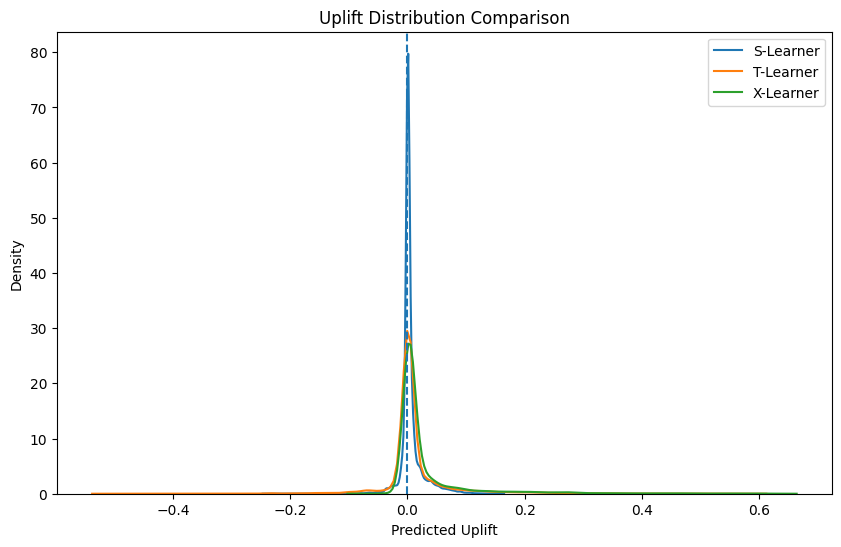

In [24]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    s_uplift,
    label="S-Learner"
)

sns.kdeplot(
    t_uplift,
    label="T-Learner"
)

sns.kdeplot(
    x_uplift,
    label="X-Learner"
)

plt.axvline(
    0,
    linestyle="--"
)

plt.title(
    "Uplift Distribution Comparison"
)

plt.xlabel(
    "Predicted Uplift"
)

plt.ylabel(
    "Density"
)

plt.legend()

plt.show()

In [25]:
def uplift_at_k(
    uplift_scores,
    fraction=0.10
):
    
    n = int(
        len(uplift_scores) *
        fraction
    )
    
    ranked_scores = np.sort(
        uplift_scores
    )[::-1]
    
    return ranked_scores[:n].mean()

In [26]:
uplift_10_results = {
    "S-Learner": uplift_at_k(
        s_uplift,
        0.10
    ),
    "T-Learner": uplift_at_k(
        t_uplift,
        0.10
    ),
    "X-Learner": uplift_at_k(
        x_uplift,
        0.10
    )
}

uplift_10_results

{'S-Learner': np.float64(0.04983359075961589),
 'T-Learner': np.float64(0.14975265394948428),
 'X-Learner': np.float64(0.21386139231118778)}

In [27]:
uplift_20_results = {
    "S-Learner": uplift_at_k(
        s_uplift,
        0.20
    ),
    "T-Learner": uplift_at_k(
        t_uplift,
        0.20
    ),
    "X-Learner": uplift_at_k(
        x_uplift,
        0.20
    )
}

uplift_20_results

{'S-Learner': np.float64(0.03244172182027891),
 'T-Learner': np.float64(0.09147406775382731),
 'X-Learner': np.float64(0.1332783382932178)}

In [28]:
def calculate_qini(
    uplift_scores,
    treatment_values,
    outcomes
):
    
    evaluation = pd.DataFrame({
        "uplift": uplift_scores,
        "treatment": np.asarray(treatment_values),
        "outcome": np.asarray(outcomes)
    })
    
    evaluation = evaluation.sort_values(
        "uplift",
        ascending=False
    ).reset_index(drop=True)
    
    evaluation["treatment_count"] = (
        evaluation["treatment"]
        .cumsum()
    )
    
    evaluation["control_count"] = (
        (1 - evaluation["treatment"])
        .cumsum()
    )
    
    evaluation["treatment_outcomes"] = (
        evaluation["treatment"] *
        evaluation["outcome"]
    ).cumsum()
    
    evaluation["control_outcomes"] = (
        (1 - evaluation["treatment"]) *
        evaluation["outcome"]
    ).cumsum()
    
    evaluation["qini"] = (
        evaluation["treatment_outcomes"]
        -
        evaluation["control_outcomes"] *
        (
            evaluation["treatment_count"] /
            evaluation["control_count"]
            .replace(0, np.nan)
        )
    )
    
    evaluation["population_fraction"] = (
        np.arange(
            1,
            len(evaluation) + 1
        ) /
        len(evaluation)
    )
    
    evaluation["qini"] = (
        evaluation["qini"]
        .fillna(0)
    )
    
    return evaluation

In [29]:
s_qini_df = calculate_qini(
    s_uplift,
    treatment_test.values,
    y_test.values
)

t_qini_df = calculate_qini(
    t_uplift,
    treatment_test.values,
    y_test.values
)

x_qini_df = calculate_qini(
    x_uplift,
    treatment_test.values,
    y_test.values
)

print("Qini curves calculated.")

Qini curves calculated.


In [30]:
s_qini = np.trapezoid(
    s_qini_df["qini"],
    s_qini_df["population_fraction"]
)

t_qini = np.trapezoid(
    t_qini_df["qini"],
    t_qini_df["population_fraction"]
)

x_qini = np.trapezoid(
    x_qini_df["qini"],
    x_qini_df["population_fraction"]
)

qini_results = {
    "S-Learner": s_qini,
    "T-Learner": t_qini,
    "X-Learner": x_qini
}

qini_results

{'S-Learner': np.float64(28.408459831048177),
 'T-Learner': np.float64(35.20443883613547),
 'X-Learner': np.float64(29.89722438139026)}

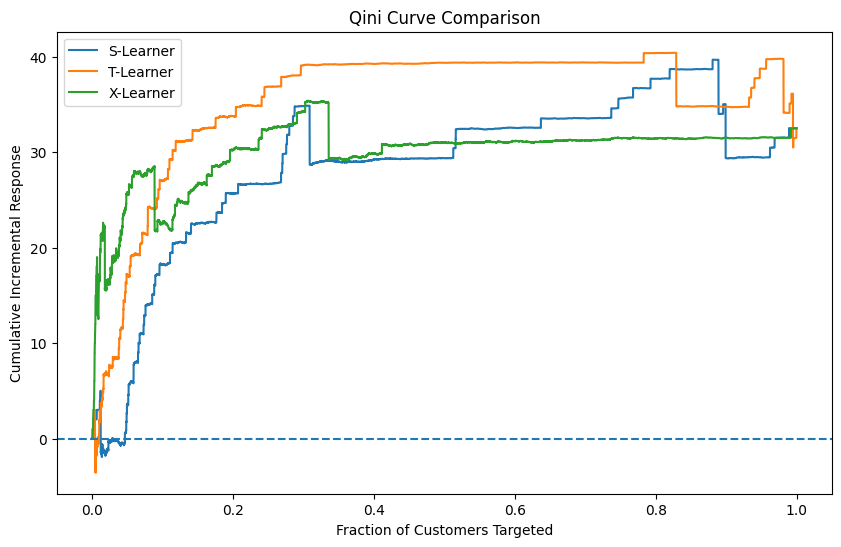

In [31]:
plt.figure(figsize=(10, 6))

plt.plot(
    s_qini_df["population_fraction"],
    s_qini_df["qini"],
    label="S-Learner"
)

plt.plot(
    t_qini_df["population_fraction"],
    t_qini_df["qini"],
    label="T-Learner"
)

plt.plot(
    x_qini_df["population_fraction"],
    x_qini_df["qini"],
    label="X-Learner"
)

plt.axhline(
    0,
    linestyle="--"
)

plt.xlabel(
    "Fraction of Customers Targeted"
)

plt.ylabel(
    "Cumulative Incremental Response"
)

plt.title(
    "Qini Curve Comparison"
)

plt.legend()

plt.show()

In [32]:
def calculate_auuc(
    uplift_scores
):
    
    ranked = np.sort(
        uplift_scores
    )[::-1]
    
    cumulative_uplift = np.cumsum(
        ranked
    )
    
    fraction = (
        np.arange(
            1,
            len(ranked) + 1
        ) /
        len(ranked)
    )
    
    return np.trapezoid(
        cumulative_uplift,
        fraction
    )

In [33]:
auuc_results = {
    "S-Learner": calculate_auuc(
        s_uplift
    ),
    "T-Learner": calculate_auuc(
        t_uplift
    ),
    "X-Learner": calculate_auuc(
        x_uplift
    )
}

auuc_results

{'S-Learner': np.float64(136.6648747684019),
 'T-Learner': np.float64(365.81499799590154),
 'X-Learner': np.float64(553.3479769820615)}

In [35]:
# S-Learner predictions under the observed treatment assignment

X_test_observed = X_test.copy()

X_test_observed["treatment"] = (
    treatment_test.values
)

s_test_prediction = (
    s_model
    .predict_proba(X_test_observed)[:, 1]
)


# T-Learner prediction under the observed treatment assignment

t_test_prediction = np.where(
    treatment_test.values == 1,
    t_pred_treatment,
    t_pred_control
)


# ROC-AUC

s_roc_auc = roc_auc_score(
    y_test,
    s_test_prediction
)

t_roc_auc = roc_auc_score(
    y_test,
    t_test_prediction
)


# PR-AUC

s_pr_auc = average_precision_score(
    y_test,
    s_test_prediction
)

t_pr_auc = average_precision_score(
    y_test,
    t_test_prediction
)


print(
    "S-Learner ROC-AUC:",
    s_roc_auc
)

print(
    "T-Learner ROC-AUC:",
    t_roc_auc
)

print(
    "S-Learner PR-AUC:",
    s_pr_auc
)

print(
    "T-Learner PR-AUC:",
    t_pr_auc
)

S-Learner ROC-AUC: 0.9285952883038863
T-Learner ROC-AUC: 0.9408564587567221
S-Learner PR-AUC: 0.17460271706158892
T-Learner PR-AUC: 0.1789522257172882


In [36]:
comparison_results = pd.DataFrame({
    "model": [
        "S-Learner",
        "T-Learner",
        "X-Learner"
    ],
    "uplift_at_10": [
        uplift_10_results["S-Learner"],
        uplift_10_results["T-Learner"],
        uplift_10_results["X-Learner"]
    ],
    "uplift_at_20": [
        uplift_20_results["S-Learner"],
        uplift_20_results["T-Learner"],
        uplift_20_results["X-Learner"]
    ],
    "qini_coefficient": [
        qini_results["S-Learner"],
        qini_results["T-Learner"],
        qini_results["X-Learner"]
    ],
    "auuc": [
        auuc_results["S-Learner"],
        auuc_results["T-Learner"],
        auuc_results["X-Learner"]
    ]
})

comparison_results

,model,uplift_at_10,uplift_at_20,qini_coefficient,auuc
0,S-Learner,0.049834,0.032442,28.408460,136.664875
1,T-Learner,0.149753,0.091474,35.204439,365.814998
2,X-Learner,0.213861,0.133278,29.897224,553.347977


In [37]:
best_model = (
    comparison_results
    .sort_values(
        "qini_coefficient",
        ascending=False
    )
    .iloc[0]["model"]
)

print(
    "Best uplift model based on Qini coefficient:"
)

print(
    best_model
)

Best uplift model based on Qini coefficient:
T-Learner


In [38]:
OUTPUT_DIR = Path(
    r"C:\Users\ugand\customer-churn-uplift-modeling\data\processed"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

comparison_path = (
    OUTPUT_DIR /
    "uplift_model_comparison.csv"
)

comparison_results.to_csv(
    comparison_path,
    index=False
)

print(
    "Comparison results saved to:"
)

print(
    comparison_path
)

Comparison results saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\uplift_model_comparison.csv


In [39]:
model_predictions = pd.DataFrame({
    "customer_index": X_test.index,
    "actual_treatment": treatment_test.values,
    "actual_conversion": y_test.values,
    "s_uplift": s_uplift,
    "t_uplift": t_uplift,
    "x_uplift": x_uplift
})

predictions_path = (
    OUTPUT_DIR /
    "uplift_model_predictions_comparison.csv"
)

model_predictions.to_csv(
    predictions_path,
    index=False
)

print(
    "Model predictions saved to:"
)

print(
    predictions_path
)

Model predictions saved to:
C:\Users\ugand\customer-churn-uplift-modeling\data\processed\uplift_model_predictions_comparison.csv


# Conclusion

## Uplift Model Comparison Summary

This notebook compared three major uplift modeling approaches:

- S-Learner
- T-Learner
- X-Learner

All models were trained and evaluated using the same development sample and test set.

### Evaluation Metrics

The models were compared using:

- Uplift@10%
- Uplift@20%
- Qini coefficient
- AUUC
- Supporting outcome-prediction metrics

### Model Selection

The Qini coefficient was selected as the primary model-selection metric because the primary objective is to rank customers according to expected incremental treatment response.

The model with the highest Qini coefficient provides the strongest treatment-ranking performance on the evaluation sample.

### Business Interpretation

The model comparison provides a more robust foundation for treatment targeting than relying on a single uplift algorithm.

Instead of selecting a model based only on conventional prediction accuracy, the project evaluates whether the model can identify customers who are most likely to benefit incrementally from treatment.

### Important Limitation

The individual treatment effect for a customer cannot be directly observed because only one treatment condition is observed for each customer.

Therefore, uplift estimates should be interpreted as model-based counterfactual estimates rather than directly observed individual effects.

The results are also based on a development sample rather than the full Criteo dataset. Further validation should be performed before production deployment.

### Next Step

The selected uplift model will be used in the next stage to build a treatment-targeting and decision framework.

The following stage will focus on:

- Treatment policy design
- Customer targeting
- Expected incremental conversions
- Treatment budget constraints
- ROI-oriented decision making